# Multi-Digit House Number Recognition with SVHN

## Introduction

Reading a house number from a street image is harder than recognizing a single cropped digit. Numbers can be blurred, tilted, poorly lit, or surrounded by other text and objects.

This project uses the Street View House Numbers (SVHN) dataset to recognize numbers containing between one and four digits. The notebook works with the original street-number images and their bounding-box annotations, crops the complete number, and trains an EfficientNetV2-based model.

The model predicts the number of digits and each digit position. Performance is measured with exact sequence accuracy, character accuracy, number-length accuracy, macro sequence accuracy, accuracy by sequence length, and confusion matrices.


In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import gc
import glob
import time
import warnings
from pathlib import Path
from zipfile import ZipFile

import cv2
import h5py
import matplotlib.pyplot as plt
import numpy as np
import requests
import tensorflow as tf

from absl import logging as absl_logging
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    Input,
    RandomContrast,
    RandomRotation,
    RandomTranslation,
    RandomZoom,
    Rescaling,
)
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
absl_logging.set_verbosity(absl_logging.ERROR)

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

TOTAL_START = time.perf_counter()

def format_time(seconds):
    seconds = int(seconds)
    hours, remainder = divmod(seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

MAX_DIGITS = 4
NUM_DIGIT_CLASSES = 10

TARGET_HEIGHT = 64
TARGET_WIDTH = 160

USE_EXTRA = True
MAX_EXTRA_RECORDS = 80_000
VALIDATION_SIZE = 0.10

MIN_TRAIN_PER_LENGTH = {
    1: 14_000,
    4: 16_000,
}

HEAD_EPOCHS = 5
FINE_TUNE_EPOCHS = 25

WORK_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
STAGE1_WEIGHTS = os.path.join(WORK_DIR, "svhn_stage1_best.weights.h5")
STAGE2_WEIGHTS = os.path.join(WORK_DIR, "svhn_stage2_best.weights.h5")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError:
        pass

    mixed_precision.set_global_policy("mixed_float16")
    DEVICE_TEXT = gpus[0].name
    BATCH_SIZE = 128
else:
    mixed_precision.set_global_policy("float32")
    DEVICE_TEXT = "CPU"
    BATCH_SIZE = 64

tf.config.optimizer.set_experimental_options({"layout_optimizer": False})

print("TensorFlow:", tf.__version__)
print("Device:", DEVICE_TEXT)
print("Precision:", mixed_precision.global_policy().name)
print("Input size:", (TARGET_HEIGHT, TARGET_WIDTH))
print("Batch size:", BATCH_SIZE)

TensorFlow: 2.20.0
Device: /physical_device:GPU:0
Precision: mixed_float16
Input size: (64, 160)
Batch size: 128


## Data Source

The notebook checks the current environment for an existing SVHN copy. If the dataset is not present, it downloads the public Kaggle dataset directly and extracts it into the working directory.

In [2]:
DATA_START = time.perf_counter()

DATASET_HANDLE = "stanfordu/street-view-house-numbers"
PUBLIC_DOWNLOAD_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "stanfordu/street-view-house-numbers"
)

CACHE_ROOT = (
    Path("/kaggle/working/svhn_data")
    if Path("/kaggle/working").exists()
    else Path.cwd() / "svhn_data"
)


def find_svhn_root(search_roots):
    matches = []

    for search_root in search_roots:
        root = Path(search_root)

        if not root.exists():
            continue

        matches.extend(
            root.rglob(
                "train_digitStruct.mat"
            )
        )

    for train_mat in matches:
        candidate = train_mat.parent

        test_mat = (
            candidate
            / "test_digitStruct.mat"
        )

        if test_mat.exists():
            return candidate.resolve()

    return None


def download_svhn(destination):
    destination.mkdir(
        parents=True,
        exist_ok=True,
    )

    archive_path = (
        destination
        / "svhn_dataset.zip"
    )

    print(
        "SVHN dataset not found locally."
    )
    print(
        "Downloading the public dataset..."
    )

    try:
        with requests.get(
            PUBLIC_DOWNLOAD_URL,
            stream=True,
            timeout=(30, 300),
            allow_redirects=True,
        ) as response:
            response.raise_for_status()

            total = int(
                response.headers.get(
                    "content-length",
                    0,
                )
            )

            downloaded = 0
            next_report = 10

            with archive_path.open(
                "wb"
            ) as file:
                for chunk in response.iter_content(
                    chunk_size=8 * 1024 * 1024
                ):
                    if not chunk:
                        continue

                    file.write(chunk)
                    downloaded += len(chunk)

                    if total > 0:
                        percent = int(
                            downloaded
                            * 100
                            / total
                        )

                        if percent >= next_report:
                            print(
                                f"  {percent}% downloaded"
                            )

                            next_report += 10

    except Exception as error:
        if archive_path.exists():
            archive_path.unlink()

        raise RuntimeError(
            "The SVHN dataset could not be downloaded. "
            "The notebook requires internet access the first time it runs."
        ) from error

    print(
        "Extracting SVHN dataset..."
    )

    try:
        with ZipFile(
            archive_path,
            "r",
        ) as archive:
            archive.extractall(
                destination
            )

    except Exception:
        if archive_path.exists():
            archive_path.unlink()

        raise

    archive_path.unlink(
        missing_ok=True
    )

    root = find_svhn_root(
        [destination]
    )

    if root is None:
        raise FileNotFoundError(
            "The downloaded archive did not contain "
            "the expected SVHN annotation files."
        )

    return root


DATA_ROOT = find_svhn_root(
    [
        "/kaggle/input",
        "/kaggle/working",
        CACHE_ROOT,
        Path.cwd(),
    ]
)

if DATA_ROOT is None:
    DATA_ROOT = download_svhn(
        CACHE_ROOT
    )

DATA_ROOT = Path(
    DATA_ROOT
).resolve()

TRAIN_MAT = (
    DATA_ROOT
    / "train_digitStruct.mat"
)

TEST_MAT = (
    DATA_ROOT
    / "test_digitStruct.mat"
)

EXTRA_MAT = (
    DATA_ROOT
    / "extra_digitStruct.mat"
)

if not TRAIN_MAT.exists():
    raise FileNotFoundError(
        f"Training annotations not found: "
        f"{TRAIN_MAT}"
    )

if not TEST_MAT.exists():
    raise FileNotFoundError(
        f"Test annotations not found: "
        f"{TEST_MAT}"
    )

if (
    USE_EXTRA
    and not EXTRA_MAT.exists()
):
    USE_EXTRA = False
    print(
        "Extra annotations were not found. "
        "Continuing without the extra set."
    )


def build_image_index(
    split_name
):
    split_root = (
        DATA_ROOT
        / split_name
    )

    paths = list(
        split_root.rglob("*.png")
    )

    return {
        path.name: str(path)
        for path in paths
    }


train_image_index = (
    build_image_index(
        "train"
    )
)

test_image_index = (
    build_image_index(
        "test"
    )
)

extra_image_index = (
    build_image_index(
        "extra"
    )
    if USE_EXTRA
    else {}
)

if not train_image_index:
    raise RuntimeError(
        "No training images were found."
    )

if not test_image_index:
    raise RuntimeError(
        "No test images were found."
    )

TRAIN_MAT = str(TRAIN_MAT)
TEST_MAT = str(TEST_MAT)
EXTRA_MAT = str(EXTRA_MAT)
DATA_ROOT = str(DATA_ROOT)

print(
    "Dataset root:",
    DATA_ROOT,
)

print(
    f"Training images found: "
    f"{len(train_image_index):,}"
)

print(
    f"Test images found:     "
    f"{len(test_image_index):,}"
)

print(
    f"Extra images found:    "
    f"{len(extra_image_index):,}"
)

SVHN dataset not found locally.
  10% downloaded
  20% downloaded
  30% downloaded
  40% downloaded
  50% downloaded
  60% downloaded
  70% downloaded
  80% downloaded
  90% downloaded
  100% downloaded
Extracting SVHN dataset...
Dataset root: /kaggle/working/svhn_data
Training images found: 33,402
Test images found:     13,068
Extra images found:    202,353


## Reading the Number Labels

Each entry in `digitStruct.mat` contains a filename and a set of bounding boxes. The boxes identify the digits that belong to the house number.

SVHN stores the digit zero as label `10`, so it is converted back to `0`. The digits are then ordered from left to right before the number is stored.

In [3]:
def decode_matlab_string(mat_file, reference):
    values = np.asarray(
        mat_file[reference][()]
    ).reshape(-1)

    return "".join(chr(int(value)) for value in values)


def read_numeric_field(mat_file, dataset):
    raw = dataset[()]

    if h5py.check_dtype(ref=raw.dtype) is not None:
        values = []

        for reference in raw.reshape(-1):
            value = np.asarray(
                mat_file[reference][()]
            ).reshape(-1)

            values.append(float(value[0]))

        return values

    return [float(value) for value in raw.reshape(-1)]


def parse_digitstruct(mat_path, max_records=None, seed=42):
    rng = np.random.default_rng(seed)
    records = []

    with h5py.File(mat_path, "r") as mat_file:
        digit_struct = mat_file["digitStruct"]

        names = digit_struct["name"]
        boxes = digit_struct["bbox"]

        total = names.shape[0]

        if max_records is not None and max_records < total:
            indices = np.sort(
                rng.choice(
                    total,
                    size=max_records,
                    replace=False,
                )
            )
        else:
            indices = np.arange(total)

        print(
            f"Reading {len(indices):,} records from "
            f"{os.path.basename(mat_path)}"
        )

        for counter, index in enumerate(indices):
            filename = decode_matlab_string(
                mat_file,
                names[index, 0],
            )

            bbox = mat_file[
                boxes[index, 0]
            ]

            labels = read_numeric_field(mat_file, bbox["label"])
            lefts = read_numeric_field(mat_file, bbox["left"])
            tops = read_numeric_field(mat_file, bbox["top"])
            widths = read_numeric_field(mat_file, bbox["width"])
            heights = read_numeric_field(mat_file, bbox["height"])

            count = min(
                len(labels),
                len(lefts),
                len(tops),
                len(widths),
                len(heights),
            )

            digits = []

            for position in range(count):
                label = int(round(labels[position]))

                if label == 10:
                    label = 0

                width = float(widths[position])
                height = float(heights[position])

                if not 0 <= label <= 9:
                    continue

                if width <= 0 or height <= 0:
                    continue

                digits.append(
                    {
                        "label": label,
                        "left": float(lefts[position]),
                        "top": float(tops[position]),
                        "width": width,
                        "height": height,
                    }
                )

            digits.sort(key=lambda item: item["left"])

            if not 1 <= len(digits) <= MAX_DIGITS:
                continue

            records.append(
                {
                    "filename": filename,
                    "digits": digits,
                    "sequence": [
                        digit["label"]
                        for digit in digits
                    ],
                }
            )

            if (counter + 1) % 10_000 == 0:
                print(f"  {counter + 1:,} processed")

    return records


train_records = parse_digitstruct(TRAIN_MAT)
test_records = parse_digitstruct(TEST_MAT)

extra_records = (
    parse_digitstruct(
        EXTRA_MAT,
        max_records=MAX_EXTRA_RECORDS,
        seed=SEED + 1,
    )
    if USE_EXTRA
    else []
)

print()
print(f"Train records: {len(train_records):,}")
print(f"Extra records: {len(extra_records):,}")
print(f"Test records:  {len(test_records):,}")

Reading 33,402 records from train_digitStruct.mat
  10,000 processed
  20,000 processed
  30,000 processed
Reading 13,068 records from test_digitStruct.mat
  10,000 processed
Reading 80,000 records from extra_digitStruct.mat
  10,000 processed
  20,000 processed
  30,000 processed
  40,000 processed
  50,000 processed
  60,000 processed
  70,000 processed
  80,000 processed

Train records: 33,392
Extra records: 79,947
Test records:  13,066


## Preparing the Number Images

The digit boxes are combined to locate the complete number. A small margin is kept around the number before resizing.

The image width is set to 160 pixels so that longer numbers retain more horizontal detail. Aspect ratio is preserved during resizing.

In [4]:
def resize_with_padding(image):
    height, width = image.shape[:2]

    if height <= 0 or width <= 0:
        return None

    scale = min(
        TARGET_WIDTH / width,
        TARGET_HEIGHT / height,
    )

    new_width = max(1, int(round(width * scale)))
    new_height = max(1, int(round(height * scale)))

    interpolation = (
        cv2.INTER_AREA
        if scale < 1
        else cv2.INTER_CUBIC
    )

    resized = cv2.resize(
        image,
        (new_width, new_height),
        interpolation=interpolation,
    )

    background = np.median(
        image.reshape(-1, 3),
        axis=0,
    ).astype(np.uint8)

    canvas = np.empty(
        (TARGET_HEIGHT, TARGET_WIDTH, 3),
        dtype=np.uint8,
    )
    canvas[:] = background

    x_offset = (TARGET_WIDTH - new_width) // 2
    y_offset = (TARGET_HEIGHT - new_height) // 2

    canvas[
        y_offset:y_offset + new_height,
        x_offset:x_offset + new_width,
    ] = resized

    return canvas


def prepare_number_images(records, image_index, name):
    images = np.empty(
        (
            len(records),
            TARGET_HEIGHT,
            TARGET_WIDTH,
            3,
        ),
        dtype=np.uint8,
    )

    labels = np.zeros(
        (len(records), MAX_DIGITS),
        dtype=np.int32,
    )

    lengths = np.zeros(
        len(records),
        dtype=np.int32,
    )

    valid = 0

    print(f"\nPreparing {name}...")

    for index, record in enumerate(records):
        image_path = image_index.get(record["filename"])

        if image_path is None:
            continue

        image = cv2.imread(
            image_path,
            cv2.IMREAD_COLOR,
        )

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB,
        )

        image_height, image_width = image.shape[:2]
        digits = record["digits"]

        left = min(digit["left"] for digit in digits)
        top = min(digit["top"] for digit in digits)

        right = max(
            digit["left"] + digit["width"]
            for digit in digits
        )

        bottom = max(
            digit["top"] + digit["height"]
            for digit in digits
        )

        box_width = right - left
        box_height = bottom - top

        pad_x = 0.05 * box_width
        pad_y = 0.08 * box_height

        x1 = max(0, int(np.floor(left - pad_x)))
        y1 = max(0, int(np.floor(top - pad_y)))

        x2 = min(
            image_width,
            int(np.ceil(right + pad_x)),
        )

        y2 = min(
            image_height,
            int(np.ceil(bottom + pad_y)),
        )

        if x2 <= x1 or y2 <= y1:
            continue

        crop = image[y1:y2, x1:x2]
        crop = resize_with_padding(crop)

        if crop is None:
            continue

        sequence = record["sequence"]
        sequence_length = len(sequence)

        images[valid] = crop
        labels[valid, :sequence_length] = sequence
        lengths[valid] = sequence_length

        valid += 1

        if (index + 1) % 10_000 == 0:
            print(f"  {index + 1:,} processed")

    print(f"{name}: {valid:,} usable images")

    return (
        images[:valid],
        labels[:valid],
        lengths[:valid],
    )


CROP_START = time.perf_counter()

X_train_main, y_train_main, len_train_main = prepare_number_images(
    train_records,
    train_image_index,
    "training set",
)

X_test, y_test, len_test = prepare_number_images(
    test_records,
    test_image_index,
    "test set",
)

if USE_EXTRA and extra_records:
    X_extra, y_extra, len_extra = prepare_number_images(
        extra_records,
        extra_image_index,
        "extra set",
    )
else:
    X_extra = None
    y_extra = None
    len_extra = None

CROP_TIME = time.perf_counter() - CROP_START

print("\nImage preparation:", format_time(CROP_TIME))


Preparing training set...
  10,000 processed
  20,000 processed
  30,000 processed
training set: 33,392 usable images

Preparing test set...
  10,000 processed
test set: 13,066 usable images

Preparing extra set...
  10,000 processed
  20,000 processed
  30,000 processed
  40,000 processed
  50,000 processed
  60,000 processed
  70,000 processed
extra set: 79,947 usable images

Image preparation: 00:01:59


## Training and Validation Data

The official training set is combined with selected extra images and then divided into training and validation sets.

Two- and three-digit numbers are naturally common in SVHN. One- and four-digit numbers are less frequent, so only those under-represented groups are resampled in the training split. Validation and test data remain unchanged.

In [5]:
if X_extra is not None and len(X_extra):
    X_all = np.concatenate(
        [X_train_main, X_extra],
        axis=0,
    )

    y_all = np.concatenate(
        [y_train_main, y_extra],
        axis=0,
    )

    len_all = np.concatenate(
        [len_train_main, len_extra],
        axis=0,
    )

    del X_train_main, y_train_main, len_train_main
    del X_extra, y_extra, len_extra
    gc.collect()

else:
    X_all = X_train_main
    y_all = y_train_main
    len_all = len_train_main

indices = np.arange(len(X_all))

train_indices, val_indices = train_test_split(
    indices,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=len_all,
)

X_train = X_all[train_indices]
y_train = y_all[train_indices]
len_train = len_all[train_indices]

X_val = X_all[val_indices]
y_val = y_all[val_indices]
len_val = len_all[val_indices]

del X_all, y_all, len_all
gc.collect()

print("Training distribution before resampling")

for length in range(1, MAX_DIGITS + 1):
    print(
        f"{length} digit(s): "
        f"{np.sum(len_train == length):,}"
    )

balance_rng = np.random.default_rng(SEED + 20)
additional_indices = []

for length, target in MIN_TRAIN_PER_LENGTH.items():
    source_indices = np.flatnonzero(len_train == length)

    if 0 < len(source_indices) < target:
        additional_indices.append(
            balance_rng.choice(
                source_indices,
                size=target - len(source_indices),
                replace=True,
            )
        )

if additional_indices:
    balanced_indices = np.concatenate(
        [
            np.arange(len(X_train)),
            *additional_indices,
        ]
    )

    balance_rng.shuffle(balanced_indices)

    X_train = X_train[balanced_indices]
    y_train = y_train[balanced_indices]
    len_train = len_train[balanced_indices]

DATA_TIME = time.perf_counter() - DATA_START

del train_records, test_records, extra_records
del train_image_index, test_image_index, extra_image_index
gc.collect()

print()
print(f"Training:   {len(X_train):,}")
print(f"Validation: {len(X_val):,}")
print(f"Test:       {len(X_test):,}")

print("\nTraining distribution after resampling")

for length in range(1, MAX_DIGITS + 1):
    print(
        f"{length} digit(s): "
        f"{np.sum(len_train == length):,}"
    )

print("\nData preparation:", format_time(DATA_TIME))

Training distribution before resampling
1 digit(s): 7,984
2 digit(s): 41,642
3 digit(s): 45,932
4 digit(s): 6,447

Training:   117,574
Validation: 11,334
Test:       13,066

Training distribution after resampling
1 digit(s): 14,000
2 digit(s): 41,642
3 digit(s): 45,932
4 digit(s): 16,000

Data preparation: 00:11:16


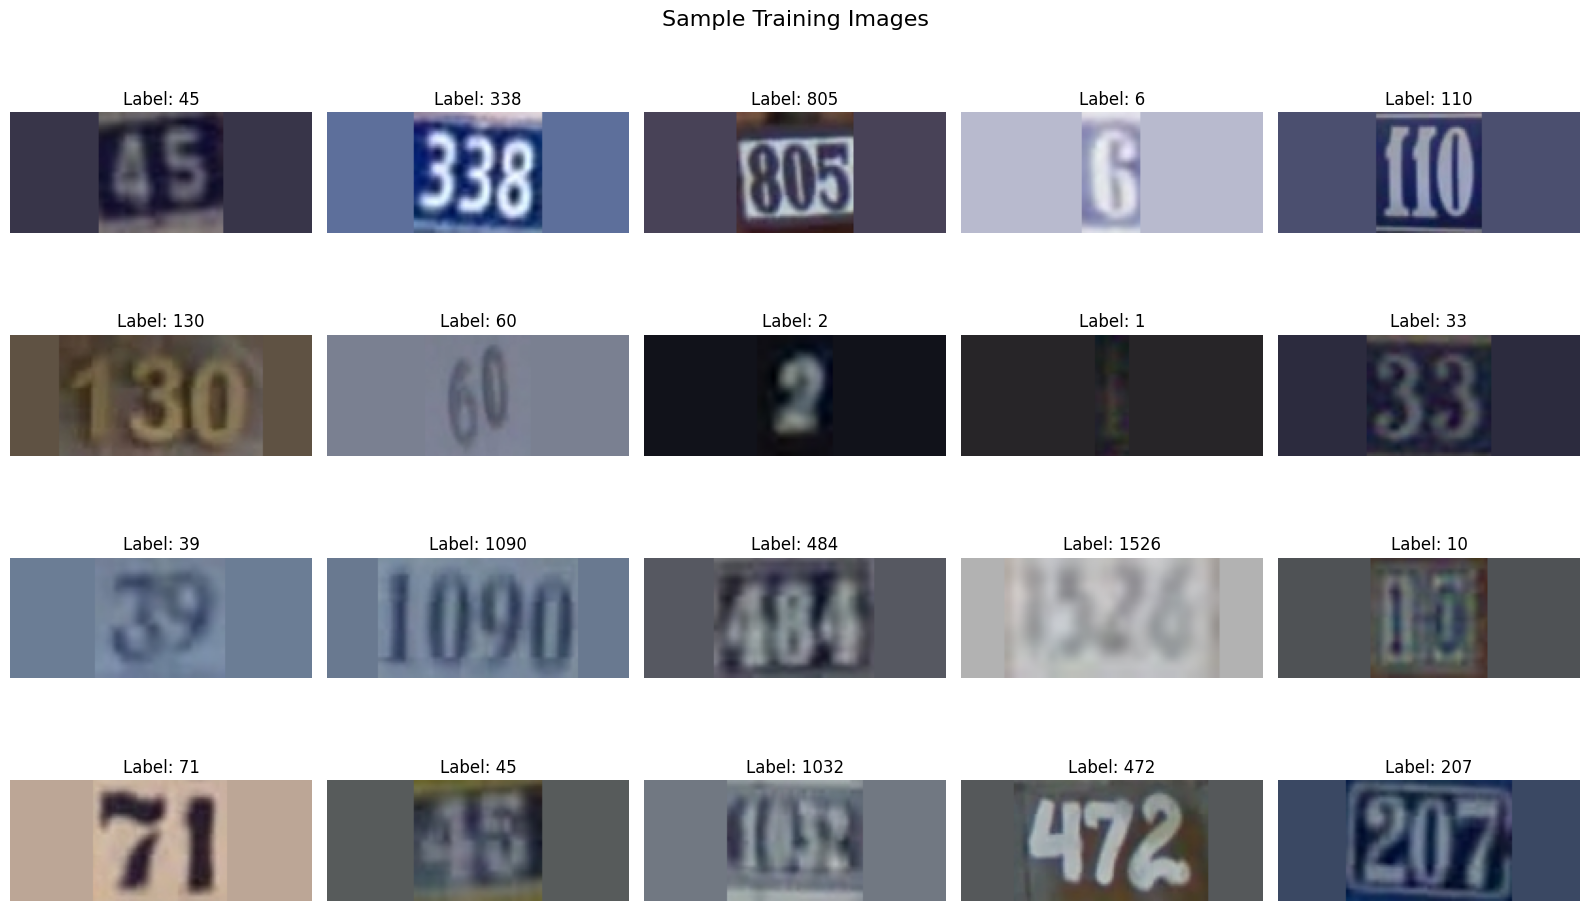

In [6]:
rng = np.random.default_rng(2026)

sample_indices = rng.choice(
    len(X_train),
    size=20,
    replace=False,
)

plt.figure(figsize=(16, 10))

for position, index in enumerate(sample_indices):
    plt.subplot(4, 5, position + 1)

    plt.imshow(X_train[index])

    number = "".join(
        str(value)
        for value in y_train[
            index,
            :len_train[index]
        ]
    )

    plt.title(f"Label: {number}")
    plt.axis("off")

plt.suptitle(
    "Sample Training Images",
    fontsize=16,
)

plt.tight_layout()
plt.show()

## Model Inputs

The model predicts sequence length separately from digit identity.

Each digit head now has only the ten real digit classes. Positions that do not exist in a shorter number are masked out of the loss instead of being trained as a blank class. This keeps every digit head focused on actual digit recognition.

In [ ]:
def create_targets(labels, lengths):
    targets = {
        "length": lengths.astype(np.int32) - 1
    }

    for position in range(MAX_DIGITS):
        targets[f"digit_{position + 1}"] = labels[:, position]

    return targets


def create_sample_weights(labels, lengths):
    counts = np.bincount(
        lengths,
        minlength=MAX_DIGITS + 1,
    )[1:]

    counts = np.maximum(counts, 1)

    length_weights = np.sqrt(
        counts.max() / counts
    )

    length_weights = (
        length_weights
        / np.mean(length_weights)
    )

    weights = {
        "length": length_weights[
            lengths - 1
        ].astype(np.float32)
    }

    for position in range(MAX_DIGITS):
        weights[
            f"digit_{position + 1}"
        ] = (
            lengths > position
        ).astype(np.float32)

    return weights


train_targets = create_targets(
    y_train,
    len_train,
)

val_targets = create_targets(
    y_val,
    len_val,
)

train_weights = create_sample_weights(
    y_train,
    len_train,
)

val_weights = create_sample_weights(
    y_val,
    len_val,
)

AUTOTUNE = tf.data.AUTOTUNE


def make_dataset(images, targets, weights, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (images, targets, weights)
    )

    if training:
        dataset = dataset.shuffle(
            min(25_000, len(images)),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=training,
    )

    return dataset.prefetch(AUTOTUNE)


train_dataset = make_dataset(
    X_train,
    train_targets,
    train_weights,
    training=True,
)

val_dataset = make_dataset(
    X_val,
    val_targets,
    val_weights,
)

val_image_dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_val)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(
    "Training batches:",
    tf.data.experimental.cardinality(
        train_dataset
    ).numpy(),
)

print(
    "Validation batches:",
    tf.data.experimental.cardinality(
        val_dataset
    ).numpy(),
)

I0000 00:00:1788098841.859827      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


## EfficientNetV2 Model

EfficientNetV2B0 is used as the image feature extractor. The shared feature representation feeds a sequence-length classifier and four position-specific digit classifiers.

The position-specific layers give each digit location its own classification capacity while retaining the shared visual features learned by the backbone.

In [ ]:
tf.keras.backend.clear_session()

image_input = Input(
    shape=(TARGET_HEIGHT, TARGET_WIDTH, 3),
    dtype=tf.uint8,
    name="image",
)

x = Rescaling(
    1.0,
    dtype="float32",
    name="uint8_to_float",
)(image_input)

x = RandomContrast(
    0.08,
    seed=SEED,
    name="contrast",
)(x)

x = RandomTranslation(
    height_factor=0.02,
    width_factor=0.02,
    fill_mode="nearest",
    seed=SEED,
    name="translation",
)(x)

x = RandomRotation(
    0.01,
    fill_mode="nearest",
    seed=SEED,
    name="rotation",
)(x)

x = RandomZoom(
    height_factor=(-0.02, 0.03),
    width_factor=(-0.02, 0.03),
    fill_mode="nearest",
    seed=SEED,
    name="zoom",
)(x)

PRETRAINED = True

try:
    backbone = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights="imagenet",
        input_shape=(
            TARGET_HEIGHT,
            TARGET_WIDTH,
            3,
        ),
        include_preprocessing=True,
    )

    backbone.trainable = False
    print("ImageNet weights loaded.")

except Exception:
    PRETRAINED = False

    backbone = tf.keras.applications.EfficientNetV2B0(
        include_top=False,
        weights=None,
        input_shape=(
            TARGET_HEIGHT,
            TARGET_WIDTH,
            3,
        ),
        include_preprocessing=True,
    )

    backbone.trainable = True
    print("Training EfficientNetV2B0 from scratch.")

features = backbone(
    x,
    training=False,
)

features = Conv2D(
    256,
    1,
    padding="same",
    activation="swish",
    name="feature_projection",
)(features)

features = BatchNormalization()(features)
features = Flatten()(features)

features = Dense(
    1024,
    activation="swish",
    name="shared_dense_1",
)(features)

features = BatchNormalization()(features)
features = Dropout(0.30)(features)

features = Dense(
    640,
    activation="swish",
    name="shared_dense_2",
)(features)

features = Dropout(0.18)(features)

length_features = Dense(
    160,
    activation="swish",
    name="length_features",
)(features)

outputs = {
    "length": Dense(
        MAX_DIGITS,
        activation="softmax",
        dtype="float32",
        name="length",
    )(length_features)
}

for position in range(1, MAX_DIGITS + 1):
    position_features = Dense(
        256,
        activation="swish",
        name=f"digit_{position}_features",
    )(features)

    position_features = Dropout(
        0.12,
        name=f"digit_{position}_dropout",
    )(position_features)

    outputs[f"digit_{position}"] = Dense(
        NUM_DIGIT_CLASSES,
        activation="softmax",
        dtype="float32",
        name=f"digit_{position}",
    )(position_features)

model = Model(
    image_input,
    outputs,
    name="SVHN_MultiDigit_Recognizer",
)


def compile_model(learning_rate):
    losses = {
        "length": SparseCategoricalCrossentropy()
    }

    loss_weights = {
        "length": 0.50
    }

    metrics = {
        "length": [
            SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    }

    for position in range(
        1,
        MAX_DIGITS + 1
    ):
        name = f"digit_{position}"

        losses[name] = (
            SparseCategoricalCrossentropy()
        )

        loss_weights[name] = 1.0

        metrics[name] = [
            SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate,
            clipnorm=5.0,
        ),
        loss=losses,
        loss_weights=loss_weights,
        metrics=metrics,
    )


compile_model(
    7e-4
    if PRETRAINED
    else 3e-4
)

model.summary()

## Training

Model selection is based on validation sequence accuracy rather than loss alone.

At the end of each epoch, validation predictions are scored separately for one-, two-, three-, and four-digit numbers. Their mean is used as the validation macro sequence score, which prevents the more common sequence lengths from dominating checkpoint selection.

In [9]:
class SequenceMonitor(Callback):
    def __init__(
        self,
        dataset,
        labels,
        lengths,
        checkpoint_path,
    ):
        super().__init__()
        self.dataset = dataset
        self.labels = labels
        self.lengths = lengths
        self.checkpoint_path = checkpoint_path
        self.best = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}

        predictions = self.model.predict(
            self.dataset,
            verbose=0,
        )

        if not isinstance(
            predictions,
            dict
        ):
            predictions = dict(
                zip(
                    self.model.output_names,
                    predictions,
                )
            )

        predicted_lengths = (
            np.argmax(
                predictions["length"],
                axis=1,
            )
            + 1
        )

        predicted_digits = np.column_stack(
            [
                np.argmax(
                    predictions[
                        f"digit_{position}"
                    ],
                    axis=1,
                )
                for position in range(
                    1,
                    MAX_DIGITS + 1
                )
            ]
        )

        per_length = []

        for length in range(
            1,
            MAX_DIGITS + 1
        ):
            mask = self.lengths == length

            if np.any(mask):
                correct_length = (
                    predicted_lengths[mask]
                    == length
                )

                correct_digits = np.all(
                    predicted_digits[
                        mask,
                        :length
                    ]
                    ==
                    self.labels[
                        mask,
                        :length
                    ],
                    axis=1,
                )

                per_length.append(
                    np.mean(
                        correct_length
                        & correct_digits
                    )
                )

        macro_accuracy = float(
            np.mean(per_length)
        )

        logs[
            "val_macro_sequence_accuracy"
        ] = macro_accuracy

        print(
            f" - val_macro_sequence_accuracy: "
            f"{macro_accuracy:.4f}"
        )

        if macro_accuracy > self.best:
            self.best = macro_accuracy

            self.model.save_weights(
                self.checkpoint_path
            )


def make_callbacks(
    checkpoint_path
):
    monitor = SequenceMonitor(
        val_image_dataset,
        y_val,
        len_val,
        checkpoint_path,
    )

    callbacks = [
        monitor,
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_delta=0.001,
            min_lr=1e-6,
            verbose=1,
        ),
        EarlyStopping(
            monitor="val_macro_sequence_accuracy",
            mode="max",
            patience=5,
            min_delta=0.001,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    return callbacks, monitor


TRAIN_START = time.perf_counter()

history_loss = []
history_val_loss = []
history_macro = []

stage1_best = -np.inf
stage1_time = 0

if PRETRAINED:
    print("\nStage 1: classification heads")

    stage1_callbacks, stage1_monitor = (
        make_callbacks(
            STAGE1_WEIGHTS
        )
    )

    start = time.perf_counter()

    history_1 = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=HEAD_EPOCHS,
        callbacks=stage1_callbacks,
        verbose=1,
    )

    stage1_time = (
        time.perf_counter()
        - start
    )

    history_loss.extend(
        history_1.history["loss"]
    )

    history_val_loss.extend(
        history_1.history["val_loss"]
    )

    history_macro.extend(
        history_1.history.get(
            "val_macro_sequence_accuracy",
            []
        )
    )

    stage1_best = stage1_monitor.best

print("\nStage 2: fine-tuning")

backbone.trainable = True

if PRETRAINED:
    freeze_until = int(
        len(backbone.layers)
        * 0.50
    )

    for layer in (
        backbone.layers[
            :freeze_until
        ]
    ):
        layer.trainable = False

    for layer in backbone.layers:
        if isinstance(
            layer,
            BatchNormalization
        ):
            layer.trainable = False

compile_model(
    5e-5
    if PRETRAINED
    else 2e-4
)

stage2_callbacks, stage2_monitor = (
    make_callbacks(
        STAGE2_WEIGHTS
    )
)

start = time.perf_counter()

history_2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=stage2_callbacks,
    verbose=1,
)

stage2_time = (
    time.perf_counter()
    - start
)

history_loss.extend(
    history_2.history["loss"]
)

history_val_loss.extend(
    history_2.history["val_loss"]
)

history_macro.extend(
    history_2.history.get(
        "val_macro_sequence_accuracy",
        []
    )
)

stage2_best = stage2_monitor.best

TRAIN_TIME = (
    time.perf_counter()
    - TRAIN_START
)

if (
    PRETRAINED
    and stage1_best
    > stage2_best
):
    model.load_weights(
        STAGE1_WEIGHTS
    )
    best_stage = "Stage 1"
    best_macro = stage1_best
else:
    model.load_weights(
        STAGE2_WEIGHTS
    )
    best_stage = "Stage 2"
    best_macro = stage2_best

print()
print("Best model:", best_stage)
print(
    "Best validation macro sequence accuracy:",
    f"{best_macro * 100:.2f}%"
)
print(
    "Training time:",
    format_time(TRAIN_TIME)
)

918/918 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - digit_1_accuracy: 0.6317 - digit_1_loss: 1.0886 - digit_2_accuracy: 0.3867 - digit_2_loss: 1.4441 - digit_3_accuracy: 0.2747 - digit_3_loss: 0.8905 - digit_4_accuracy: 0.1946 - digit_4_loss: 0.2201 - length_accuracy: 0.7892 - length_loss: 0.4350 - loss: 3.8609 - val_macro_sequence_accuracy: 0.4698
918/918 ━━━━━━━━━━━━━━━━━━━━ 96s 78ms/step - digit_1_accuracy: 0.7102 - digit_1_loss: 0.8513 - digit_2_accuracy: 0.4727 - digit_2_loss: 1.1990 - digit_3_accuracy: 0.3247 - digit_3_loss: 0.7398 - digit_4_accuracy: 0.1907 - digit_4_loss: 0.1712 - length_accuracy: 0.8347 - length_loss: 0.3493 - loss: 3.1360 - val_digit_1_accuracy: 0.7912 - val_digit_1_loss: 0.6188 - val_digit_2_accuracy: 0.6256 - val_digit_2_loss: 0.8817 - val_digit_3_accuracy: 0.4143 - val_digit_3_loss: 0.4616 - val_digit_4_accuracy: 0.1316 - val_digit_4_loss: 0.0573 - val_length_accuracy: 0.8807 - val_length_loss: 0.2122 - val_loss: 2.1249 - val_macro_sequence_accuracy: 0.4698 - lear

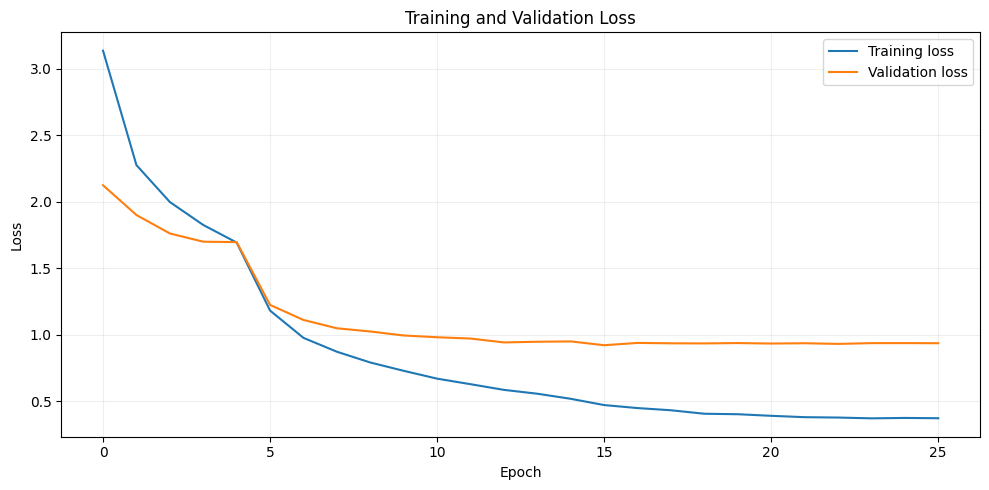

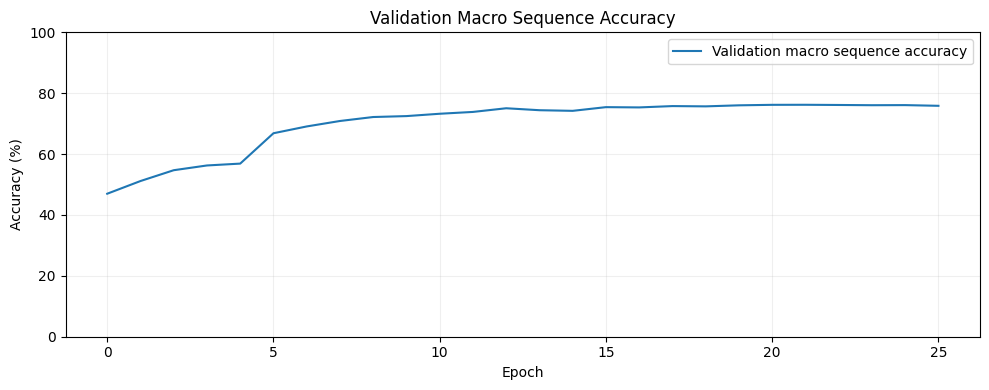

In [10]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    history_loss,
    label="Training loss",
)

ax.plot(
    history_val_loss,
    label="Validation loss",
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

if history_macro:
    plt.figure(figsize=(10, 4))

    plt.plot(
        np.array(history_macro) * 100,
        label="Validation macro sequence accuracy",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(
        "Validation Macro Sequence Accuracy"
    )
    plt.ylim(0, 100)
    plt.grid(alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

## Test Evaluation

In [ ]:
EVAL_START = time.perf_counter()

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_test)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

predictions = model.predict(
    test_dataset,
    verbose=1,
)

if not isinstance(
    predictions,
    dict
):
    predictions = dict(
        zip(
            model.output_names,
            predictions,
        )
    )

predicted_lengths = (
    np.argmax(
        predictions["length"],
        axis=1,
    )
    + 1
)

predicted_digits = np.column_stack(
    [
        np.argmax(
            predictions[
                f"digit_{position}"
            ],
            axis=1,
        )
        for position in range(
            1,
            MAX_DIGITS + 1
        )
    ]
)

true_sequences = []
predicted_sequences = []

for index in range(
    len(X_test)
):
    true_sequence = (
        y_test[
            index,
            :len_test[index]
        ]
        .astype(int)
        .tolist()
    )

    predicted_sequence = (
        predicted_digits[
            index,
            :predicted_lengths[index]
        ]
        .astype(int)
        .tolist()
    )

    true_sequences.append(
        true_sequence
    )

    predicted_sequences.append(
        predicted_sequence
    )

103/103 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step


In [ ]:
GAP = 10


def align_sequences(
    true_sequence,
    predicted_sequence
):
    n = len(true_sequence)
    m = len(predicted_sequence)

    distance = np.zeros(
        (n + 1, m + 1),
        dtype=np.int32,
    )

    distance[:, 0] = np.arange(
        n + 1
    )

    distance[0, :] = np.arange(
        m + 1
    )

    for i in range(
        1,
        n + 1
    ):
        for j in range(
            1,
            m + 1
        ):
            cost = (
                0
                if true_sequence[i - 1]
                == predicted_sequence[j - 1]
                else 1
            )

            distance[i, j] = min(
                distance[i - 1, j] + 1,
                distance[i, j - 1] + 1,
                distance[i - 1, j - 1] + cost,
            )

    aligned_true = []
    aligned_pred = []

    i, j = n, m

    while i > 0 or j > 0:
        if i > 0 and j > 0:
            cost = (
                0
                if true_sequence[i - 1]
                == predicted_sequence[j - 1]
                else 1
            )

            if (
                distance[i, j]
                ==
                distance[i - 1, j - 1]
                + cost
            ):
                aligned_true.append(
                    true_sequence[i - 1]
                )

                aligned_pred.append(
                    predicted_sequence[j - 1]
                )

                i -= 1
                j -= 1
                continue

        if (
            i > 0
            and (
                j == 0
                or distance[i, j]
                ==
                distance[i - 1, j]
                + 1
            )
        ):
            aligned_true.append(
                true_sequence[i - 1]
            )

            aligned_pred.append(
                GAP
            )

            i -= 1

        else:
            aligned_true.append(
                GAP
            )

            aligned_pred.append(
                predicted_sequence[j - 1]
            )

            j -= 1

    aligned_true.reverse()
    aligned_pred.reverse()

    return (
        aligned_true,
        aligned_pred,
        int(distance[n, m]),
    )


exact_correct = 0
length_correct = 0

total_edit_distance = 0
total_characters = 0

confusion_true = []
confusion_pred = []

for (
    true_sequence,
    predicted_sequence
) in zip(
    true_sequences,
    predicted_sequences,
):
    if (
        true_sequence
        ==
        predicted_sequence
    ):
        exact_correct += 1

    if (
        len(true_sequence)
        ==
        len(predicted_sequence)
    ):
        length_correct += 1

    (
        aligned_true,
        aligned_pred,
        edit_distance,
    ) = align_sequences(
        true_sequence,
        predicted_sequence,
    )

    confusion_true.extend(
        aligned_true
    )

    confusion_pred.extend(
        aligned_pred
    )

    total_edit_distance += (
        edit_distance
    )

    total_characters += len(
        true_sequence
    )


exact_accuracy = (
    exact_correct
    / len(true_sequences)
)

length_accuracy = (
    length_correct
    / len(true_sequences)
)

character_accuracy = max(
    0.0,
    1.0
    -
    total_edit_distance
    / total_characters,
)

accuracy_by_length = {}
test_count_by_length = {}

for length in range(
    1,
    MAX_DIGITS + 1
):
    indices = np.where(
        len_test == length
    )[0]

    test_count_by_length[
        length
    ] = len(indices)

    correct = sum(
        true_sequences[index]
        ==
        predicted_sequences[index]
        for index in indices
    )

    accuracy_by_length[
        length
    ] = (
        correct / len(indices)
        if len(indices)
        else 0.0
    )

macro_sequence_accuracy = np.mean(
    [
        accuracy_by_length[length]
        for length in range(
            1,
            MAX_DIGITS + 1
        )
    ]
)

multi_indices = np.where(
    len_test >= 2
)[0]

long_indices = np.where(
    len_test >= 3
)[0]

multi_accuracy = (
    np.mean(
        [
            true_sequences[index]
            ==
            predicted_sequences[index]
            for index in multi_indices
        ]
    )
    if len(multi_indices)
    else 0.0
)

long_accuracy = (
    np.mean(
        [
            true_sequences[index]
            ==
            predicted_sequences[index]
            for index in long_indices
        ]
    )
    if len(long_indices)
    else 0.0
)

position_accuracy = {}

for position in range(
    MAX_DIGITS
):
    active = (
        len_test > position
    )

    position_accuracy[
        position + 1
    ] = np.mean(
        predicted_digits[
            active,
            position
        ]
        ==
        y_test[
            active,
            position
        ]
    )

four_digit_mask = (
    len_test == 4
)

four_digit_character_accuracy = (
    np.mean(
        predicted_digits[
            four_digit_mask,
            :4
        ]
        ==
        y_test[
            four_digit_mask,
            :4
        ]
    )
    if np.any(
        four_digit_mask
    )
    else 0.0
)

four_digit_length_accuracy = (
    np.mean(
        predicted_lengths[
            four_digit_mask
        ]
        == 4
    )
    if np.any(
        four_digit_mask
    )
    else 0.0
)

EVAL_TIME = (
    time.perf_counter()
    - EVAL_START
)

print("\nFinal results")
print("-" * 52)

print(
    f"Exact sequence accuracy : "
    f"{exact_accuracy * 100:.2f}%"
)

print(
    f"Macro sequence accuracy : "
    f"{macro_sequence_accuracy * 100:.2f}%"
)

print(
    f"Character accuracy      : "
    f"{character_accuracy * 100:.2f}%"
)

print(
    f"Correct length accuracy : "
    f"{length_accuracy * 100:.2f}%"
)

print(
    f"2–4 digit accuracy      : "
    f"{multi_accuracy * 100:.2f}%"
)

print(
    f"3–4 digit accuracy      : "
    f"{long_accuracy * 100:.2f}%"
)

print()

for length in range(
    1,
    MAX_DIGITS + 1
):
    print(
        f"{length}-digit accuracy       : "
        f"{accuracy_by_length[length] * 100:.2f}% "
        f"({test_count_by_length[length]:,} samples)"
    )

print()
print(
    f"4-digit character acc.  : "
    f"{four_digit_character_accuracy * 100:.2f}%"
)

print(
    f"4-digit length accuracy : "
    f"{four_digit_length_accuracy * 100:.2f}%"
)

print("\nActive digit accuracy by position")

for position in range(
    1,
    MAX_DIGITS + 1
):
    print(
        f"Position {position}: "
        f"{position_accuracy[position] * 100:.2f}%"
    )


Final results
----------------------------------------------------
Exact sequence accuracy : 75.40%
Macro sequence accuracy : 66.60%
Character accuracy      : 84.65%
Correct length accuracy : 95.51%
2–4 digit accuracy      : 72.66%
3–4 digit accuracy      : 61.07%

1-digit accuracy       : 87.07% (2,483 samples)
2-digit accuracy       : 75.75% (8,356 samples)
3-digit accuracy       : 62.47% (2,081 samples)
4-digit accuracy       : 41.10% (146 samples)

4-digit character acc.  : 77.74%
4-digit length accuracy : 84.25%

Active digit accuracy by position
Position 1: 87.99%
Position 2: 83.67%
Position 3: 81.54%
Position 4: 84.25%


## Number-Length Performance

Exact sequence accuracy becomes stricter as the number of digits increases because every position must be correct. The chart compares each sequence length using the untouched official test set.

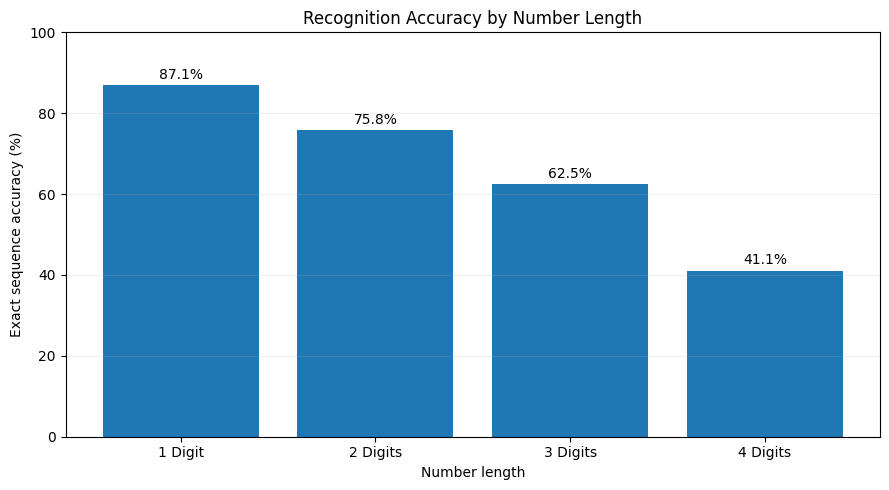

In [ ]:
length_names = [
    "1 Digit",
    "2 Digits",
    "3 Digits",
    "4 Digits",
]

length_values = [
    accuracy_by_length[length]
    * 100
    for length in range(
        1,
        5
    )
]

plt.figure(
    figsize=(9, 5)
)

bars = plt.bar(
    length_names,
    length_values,
)

plt.ylim(0, 100)
plt.ylabel(
    "Exact sequence accuracy (%)"
)
plt.xlabel(
    "Number length"
)
plt.title(
    "Recognition Accuracy by Number Length"
)

for bar, value in zip(
    bars,
    length_values,
):
    plt.text(
        bar.get_x()
        + bar.get_width()
        / 2,
        min(
            value + 1.5,
            98
        ),
        f"{value:.1f}%",
        ha="center",
    )

plt.grid(
    axis="y",
    alpha=0.2,
)

plt.tight_layout()
plt.show()

## Confusion Matrix

The digit confusion matrix is based only on the final test predictions. Rows are normalized to percentages and each cell also shows the case count.

`Gap` represents a missing or extra digit rather than a substitution.

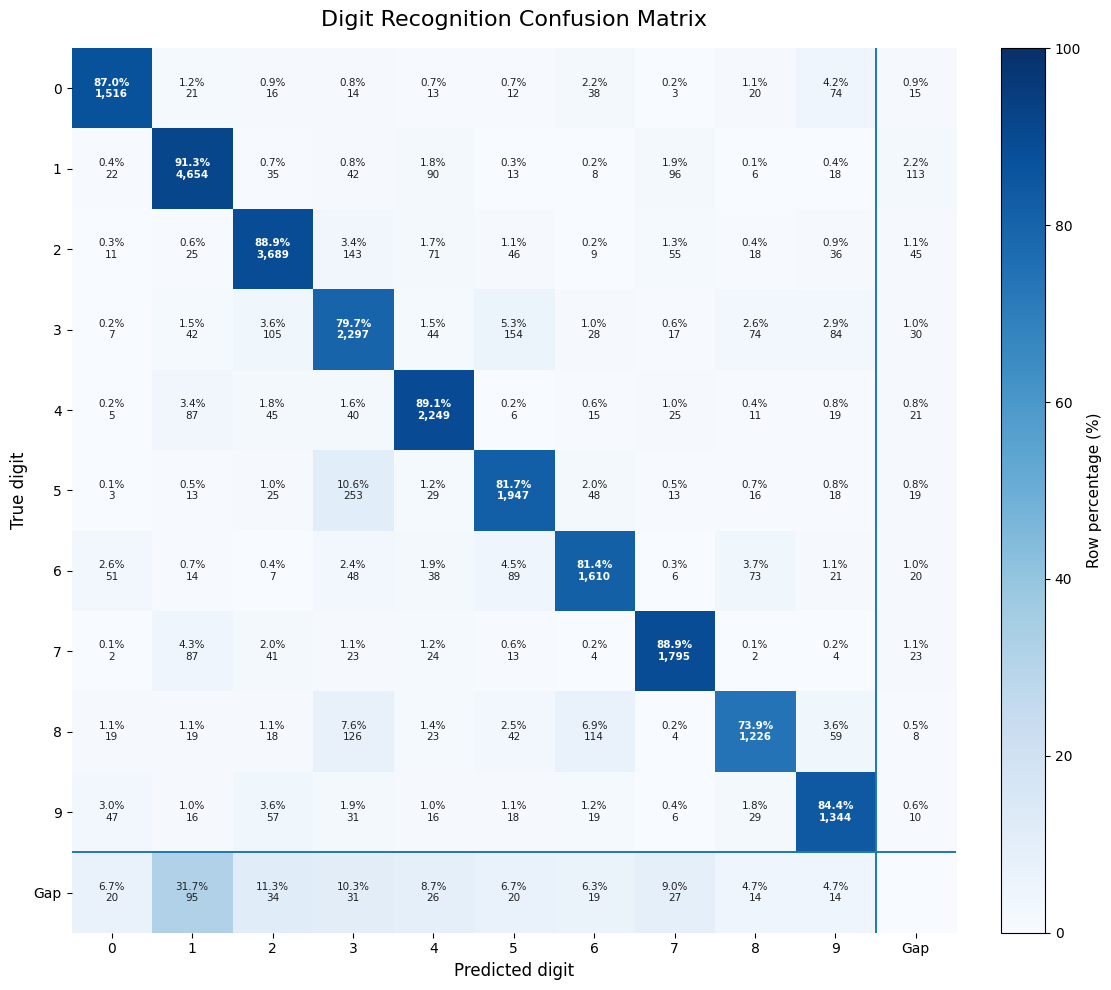

In [ ]:
digit_labels = list(range(11))

digit_cm = confusion_matrix(
    confusion_true,
    confusion_pred,
    labels=digit_labels,
)

row_totals = digit_cm.sum(
    axis=1,
    keepdims=True,
)

digit_cm_percent = np.divide(
    digit_cm,
    row_totals,
    out=np.zeros_like(
        digit_cm,
        dtype=float,
    ),
    where=row_totals != 0,
) * 100


display_labels = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9",
    "Gap",
]


fig, ax = plt.subplots(
    figsize=(12, 10)
)

image = ax.imshow(
    digit_cm_percent,
    cmap="Blues",
    vmin=0,
    vmax=100,
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Row percentage (%)",
    fontsize=11,
)

ax.set_xticks(
    np.arange(len(display_labels))
)

ax.set_yticks(
    np.arange(len(display_labels))
)

ax.set_xticklabels(
    display_labels,
    fontsize=10,
)

ax.set_yticklabels(
    display_labels,
    fontsize=10,
)

ax.set_xlabel(
    "Predicted digit",
    fontsize=12,
)

ax.set_ylabel(
    "True digit",
    fontsize=12,
)

ax.set_title(
    "Digit Recognition Confusion Matrix",
    fontsize=16,
    pad=16,
)

for row in range(
    digit_cm.shape[0]
):
    for column in range(
        digit_cm.shape[1]
    ):
        count = digit_cm[
            row,
            column
        ]

        percentage = digit_cm_percent[
            row,
            column
        ]

        if count == 0:
            continue

        text_color = (
            "white"
            if percentage >= 45
            else "#202020"
        )

        ax.text(
            column,
            row,
            f"{percentage:.1f}%\n{count:,}",
            ha="center",
            va="center",
            fontsize=7.5,
            color=text_color,
            fontweight=(
                "bold"
                if row == column
                else "normal"
            ),
        )


boundary = (
    len(display_labels)
    - 1.5
)

ax.axhline(
    boundary,
    linewidth=1.4,
)

ax.axvline(
    boundary,
    linewidth=1.4,
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Number-Length Confusion Matrix

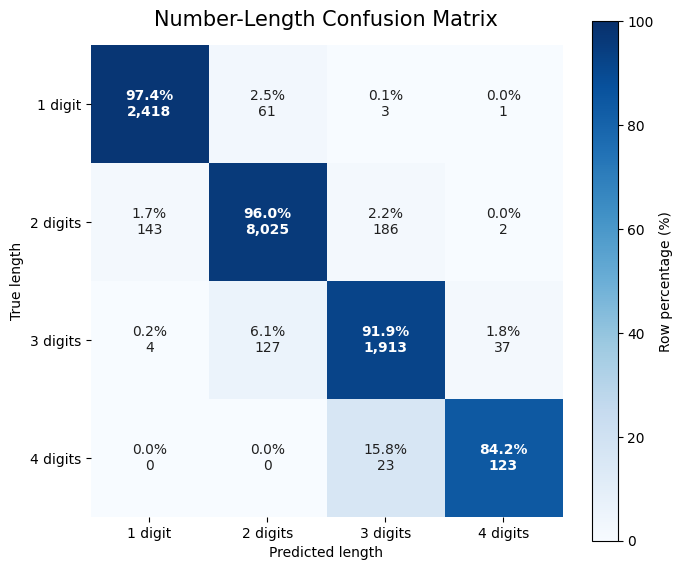

In [ ]:
true_length_classes = (
    len_test - 1
)

predicted_length_classes = (
    predicted_lengths - 1
)


length_cm = confusion_matrix(
    true_length_classes,
    predicted_length_classes,
    labels=[0, 1, 2, 3],
)


length_totals = length_cm.sum(
    axis=1,
    keepdims=True,
)


length_percent = np.divide(
    length_cm,
    length_totals,
    out=np.zeros_like(
        length_cm,
        dtype=float,
    ),
    where=length_totals != 0,
) * 100


fig, ax = plt.subplots(
    figsize=(7, 6)
)

image = ax.imshow(
    length_percent,
    cmap="Blues",
    vmin=0,
    vmax=100,
)

fig.colorbar(
    image,
    ax=ax,
).set_label(
    "Row percentage (%)"
)


length_labels = [
    "1 digit",
    "2 digits",
    "3 digits",
    "4 digits",
]


ax.set_xticks(
    np.arange(4)
)

ax.set_yticks(
    np.arange(4)
)

ax.set_xticklabels(
    length_labels
)

ax.set_yticklabels(
    length_labels
)

ax.set_xlabel(
    "Predicted length"
)

ax.set_ylabel(
    "True length"
)

ax.set_title(
    "Number-Length Confusion Matrix",
    fontsize=15,
    pad=14,
)


for row in range(4):
    for column in range(4):
        percentage = length_percent[
            row,
            column
        ]

        count = length_cm[
            row,
            column
        ]

        ax.text(
            column,
            row,
            f"{percentage:.1f}%\n{count:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if percentage >= 45
                else "#202020"
            ),
            fontweight=(
                "bold"
                if row == column
                else "normal"
            ),
        )


for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## Sample Predictions

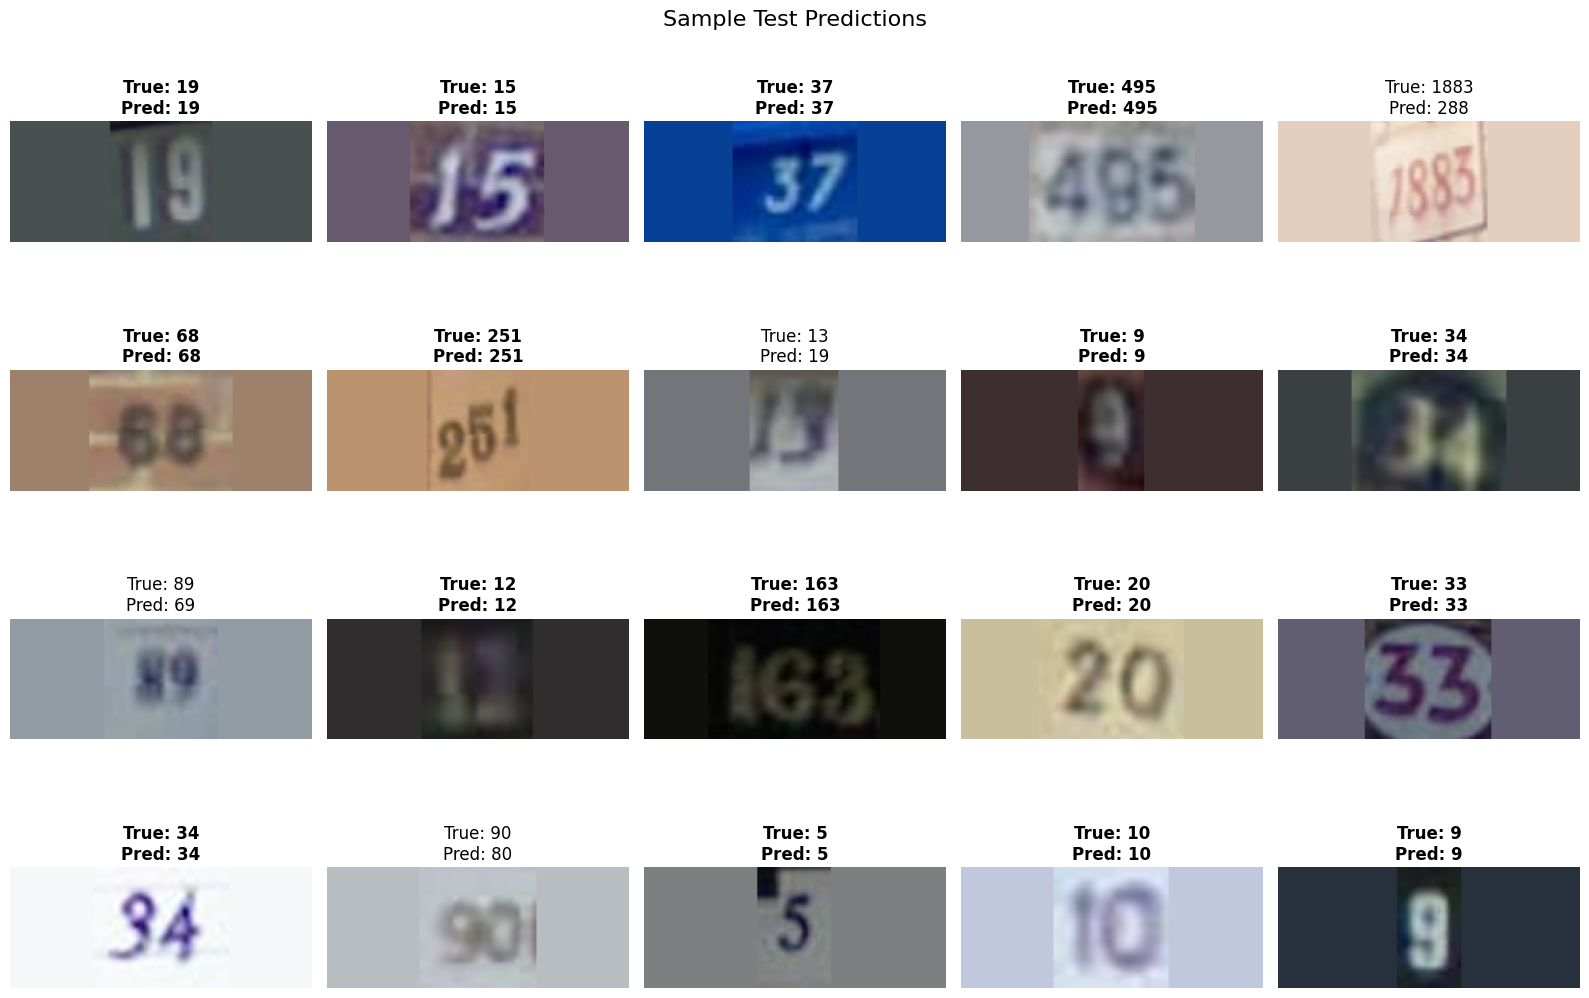

In [ ]:
rng = np.random.default_rng(2027)

sample_indices = rng.choice(
    len(X_test),
    size=20,
    replace=False,
)

plt.figure(figsize=(16, 11))

for position, index in enumerate(sample_indices):
    plt.subplot(
        4,
        5,
        position + 1,
    )

    plt.imshow(
        X_test[index]
    )

    true_number = "".join(
        map(
            str,
            true_sequences[index],
        )
    )

    predicted_number = "".join(
        map(
            str,
            predicted_sequences[index],
        )
    )

    correct = (
        true_sequences[index]
        ==
        predicted_sequences[index]
    )

    plt.title(
        f"True: {true_number}\n"
        f"Pred: {predicted_number}",
        fontweight=(
            "bold"
            if correct
            else "normal"
        ),
    )

    plt.axis("off")


plt.suptitle(
    "Sample Test Predictions",
    fontsize=16,
)

plt.tight_layout()
plt.show()

## Runtime

In [ ]:
TOTAL_TIME = (
    time.perf_counter()
    - TOTAL_START
)


print("Runtime Summary")
print("-" * 44)

print(
    f"Image preparation : "
    f"{format_time(CROP_TIME)}"
)

print(
    f"Data preparation  : "
    f"{format_time(DATA_TIME)}"
)

if PRETRAINED:
    print(
        f"Stage 1 training  : "
        f"{format_time(stage1_time)}"
    )

print(
    f"Stage 2 training  : "
    f"{format_time(stage2_time)}"
)

print(
    f"Total training    : "
    f"{format_time(TRAIN_TIME)}"
)

print(
    f"Evaluation        : "
    f"{format_time(EVAL_TIME)}"
)

print(
    f"Full notebook     : "
    f"{format_time(TOTAL_TIME)}"
)

Runtime Summary
--------------------------------------------
Image preparation : 00:01:59
Data preparation  : 00:11:16
Stage 1 training  : 00:05:58
Stage 2 training  : 00:33:55
Total training    : 00:39:54
Evaluation        : 00:00:06
Full notebook     : 00:51:37


## Conclusion

The model achieved **75.40% exact sequence accuracy**, **84.65% character accuracy**, and **95.51% number-length accuracy** on the SVHN test set.

Accuracy by sequence length was **87.07% for one digit**, **75.75% for two digits**, **62.47% for three digits**, and **41.10% for four digits**.

The results show that recognition becomes more difficult as sequence length increases, but the model performs consistently well on shorter and medium-length house numbers while maintaining strong digit-level and length prediction accuracy.